## --> Import library

In [1]:
import os # where the path is
import numpy as np # mathematical calculation
import pandas as pd # data manipulation
import matplotlib.pyplot as plt # data visuliasation
import seaborn as sns # data visuliasation
sns.set  
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows',500)
pd.set_option('display.max_columns',50)
pd.set_option('display.width',1000)

## --> Import data set

In [ ]:
# by default controlling height and width of plot
# by default controlling height and width of plot

In [3]:
USAHOUSING = pd.read_csv('USA_Housing.csv')

In [ ]:
#USAHOUSING_1 = pd.read_csv("D:\\desktop\\ML\\DATA\\USA_Housing.csv")

In [ ]:
#USAHOUSING_2 = pd.read_csv("D:/desktop/ML/DATA/USA_Housing.csv")

## TO VIEW THE DATA SET

In [ ]:
USAHOUSING.head()

In [ ]:
USAHOUSING.tail()

## --->To get the name of all columns

In [ ]:
USAHOUSING.shape

In [4]:
USAHOUSING.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'], dtype='str')

In [ ]:
#USAHOUSING.Avg_Area_Income

### _--->There is an ambiguty in representation of name i.e. '.' this may cause problem. So we replace it with '_'
### --->Similary you can do for other issues in names.

In [5]:
USAHOUSING.columns=USAHOUSING.columns.str.replace(' ','_')


In [6]:
USAHOUSING.columns

Index(['Avg._Area_Income', 'Avg._Area_House_Age', 'Avg._Area_Number_of_Rooms', 'Avg._Area_Number_of_Bedrooms', 'Area_Population', 'Price', 'Address'], dtype='str')

In [7]:
USAHOUSING.columns=USAHOUSING.columns.str.replace('.', '')

In [8]:
USAHOUSING.columns

Index(['Avg_Area_Income', 'Avg_Area_House_Age', 'Avg_Area_Number_of_Rooms', 'Avg_Area_Number_of_Bedrooms', 'Area_Population', 'Price', 'Address'], dtype='str')

### --->To find information about data like number of column , number of rows, number of null, type of data.

In [ ]:
USAHOUSING.info()


# To get statistical information like number of counts, mean value, standard deviation, minimum, maxmimum,median(50%) etc use describe

In [ ]:
#USAHOUSING.describe(include='all')
USAHOUSING.describe()

### ---> To find unique values of each variable use this for loop on USAHOUSING.columns

In [10]:
USAHOUSING['Avg_Area_House_Age'].unique()

array([5.68286132, 6.00289981, 5.86588984, ..., 7.25059062, 5.53438842,
       5.99230531], shape=(5000,))

In [ ]:
for col in USAHOUSING.columns:
    print("*************", col, "*************")
    print(USAHOUSING[col].unique())
    print()

In [ ]:
for col in USAHOUSING.columns:
    print("*************", col, "*************")
    print("Unique values:", USAHOUSING[col].nunique())
    print()

# Address is non-significant variable to predict USA Housing price. hence, we can drop this variable


In [ ]:
USAHousing_clean = USAHOUSING.drop("Address", axis=1)

### ---> ANOVA TESTING TO CHECK SIGNIFICANT VARIABLE as it gives 'P'value whose value gives us idea about the relvance of that variable.
### ---> Since Address have p value < 5% ,So we can drop it as it is less significant.

In [ ]:
USAHousing_clean.columns

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Avg_Area_Income', data = USAHousing_clean).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

In [ ]:
# As  p value is less than SL so we can reject the null hypothesis: Means--> there is significant relation between price and Avg_Area_Income 

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Area_Population', data = USAHousing_clean).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
# typ = 2 --> we are ignoring any interaction between two features, means, x1,x2 but not in x1.x2
# typ = 1 Sequence matters
# typ = 3 interaction can not be ignored.
print(anova_result)

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('Price ~ Avg_Area_House_Age', data = USAHousing_clean).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

### To find information about missing Value 

In [ ]:
USAHousing_clean.isnull().sum()

In [ ]:
USAHousing_clean.isnull().sum()/len(USAHOUSING)*100

### To remove or replace abnormal input like(/,?,.,etc.) if any , than we can do:
### df = df.replace('?', np.nan)
### df = df.apply(lambda x : x.fillna(x.median()),axis = 0)

### To check presence of  OUTLIER and decide what to use either mean or median to impute missing value we can use boxplot
####  -If there are outliers use median else go with mean

In [ ]:
sns.boxplot(y = 'Avg_Area_Income' , data = USAHousing_clean)
plt.show()

In [ ]:
sns.boxplot(y = 'Avg_Area_Number_of_Rooms' , data = USAHousing_clean)
plt.show()

In [ ]:
sns.boxplot(y = 'Avg_Area_Number_of_Bedrooms' , data = USAHousing_clean)
plt.show()

###  Imputation of missing value.

In [ ]:
USAHousing_clean['Avg_Area_Income'] = USAHousing_clean['Avg_Area_Income'].fillna( USAHousing_clean['Avg_Area_Income'].median())

In [ ]:
USAHousing_clean.isnull().sum()/len(USAHOUSING)*100

In [ ]:
USAHousing_clean['Avg_Area_Number_of_Rooms'] = USAHousing_clean['Avg_Area_Number_of_Rooms'].fillna( USAHousing_clean['Avg_Area_Number_of_Rooms'].median())

In [ ]:
USAHousing_clean['Avg_Area_Number_of_Bedrooms'] = USAHousing_clean['Avg_Area_Number_of_Bedrooms'].fillna( USAHousing_clean['Avg_Area_Number_of_Bedrooms'].median())

In [ ]:
USAHousing_clean.isnull().sum()

###  Distribution plots to check whether data is normally distributed or not.
### ----> no of bed room have non normal data.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def distplots(col):
    plt.figure(figsize=(6,4))
    sns.histplot(USAHousing_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
for col in USAHousing_clean.columns:
    distplots(col)

# The distribution shows clustered patterns, which is expected since bedroom counts are inherently discrete. Normality of predictors is not required for linear regression.

#### ----> To view the outliers we use box plot

In [ ]:
def boxplots(col):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=USAHousing_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
for col in USAHousing_clean.select_dtypes(exclude=['object']).columns:
    boxplots(col)

###  Don't touch the dependent variable for outliers

##  find Q1, ,Q3 ,IQR, Upper Limit,Lower limit to handle outliers
##  use Z score approach by your self to see the difference

In [ ]:
USAHousing_clean.columns

In [ ]:
Q1 = USAHousing_clean.quantile(0.25)
Q3 = USAHousing_clean.quantile(0.75)
IQR = Q3-Q1
Upper_Limit = Q3+1.5*IQR
Lower_Limit = Q1-1.5*IQR

In [ ]:
outliers = ((USAHousing_clean < Lower_Limit) | (USAHousing_clean > Upper_Limit))

outliers.sum()

In [ ]:
print('Q1')
print(Q1)
print('******'*5)
print('Q3')
print(Q3)
print('******'*5)   
print('IQR')
print(IQR)
print('******'*5)  
print('Upper_Limit')
print(Upper_Limit)
print('******'*5) 
print('Lower_Limit')
print(Lower_Limit)

In [ ]:
outlier_percentage = (outliers.sum() / len(USAHousing_clean)) * 100
print(outlier_percentage)

#### USE CAPPING MEHTOD TO HANDLE OUTLIER IN 


In [ ]:
Income_Q1 = USAHousing_clean['Avg_Area_Income'].quantile(0.25)
Income_Q3 = USAHousing_clean['Avg_Area_Income'].quantile(0.75)
Income_IQR = Income_Q3 - Income_Q1
Income_Upper =Income_Q3 + Income_IQR*1.5
Income_Lower = Income_Q1 - Income_IQR*1.5

In [ ]:
#USAHousing_clean['Avg_Area_Income'] = USAHousing_clean['Avg_Area_Income'].clip(lower=Income_Lower,upper=Income_Upper)

In [ ]:
USAHousing_clean['Avg_Area_Income'] = np.where(USAHousing_clean['Avg_Area_Income']>Income_Upper,Income_Upper, 
                                              np.where(USAHousing_clean['Avg_Area_Income']<Income_Lower,Income_Lower,
                                                      USAHousing_clean['Avg_Area_Income']))

In [ ]:
USAHousing_clean['Avg_Area_Income'].describe()

In [ ]:
USAHOUSING['Avg_Area_Income'].describe()

In [ ]:
Age_Q1 = USAHousing_clean['Avg_Area_House_Age'].quantile(0.25)
Age_Q3 = USAHousing_clean['Avg_Area_House_Age'].quantile(0.75)
Age_IQR = Age_Q3 - Age_Q1
Age_Upper =Age_Q3 + Age_IQR*1.5
Age_Lower = Age_Q1 - Age_IQR*1.5

In [ ]:
USAHousing_clean['Avg_Area_House_Age'] = np.where(USAHousing_clean['Avg_Area_House_Age']>Age_Upper,Age_Upper, 
                                              np.where(USAHousing_clean['Avg_Area_House_Age']<Age_Lower,Age_Lower,
                                                       USAHousing_clean['Avg_Area_House_Age']))

In [ ]:
Number_of_Rooms_Q1 = USAHousing_clean['Avg_Area_Number_of_Rooms'].quantile(0.25)
Number_of_Rooms_Q3 = USAHousing_clean['Avg_Area_Number_of_Rooms'].quantile(0.75)
Number_of_Rooms_IQR = Number_of_Rooms_Q3 - Number_of_Rooms_Q1
Number_of_Rooms_Upper =Number_of_Rooms_Q3 + Number_of_Rooms_IQR*1.5
Number_of_Rooms_Lower = Number_of_Rooms_Q1 - Number_of_Rooms_IQR*1.5

In [ ]:
USAHousing_clean['Avg_Area_Number_of_Rooms'] = np.where(USAHousing_clean['Avg_Area_Number_of_Rooms']>Number_of_Rooms_Upper,Number_of_Rooms_Upper, 
                                              np.where(USAHousing_clean['Avg_Area_Number_of_Rooms']<Number_of_Rooms_Lower ,Number_of_Rooms_Lower ,
                                                       USAHousing_clean['Avg_Area_Number_of_Rooms']))

In [ ]:
Population_Q1 = USAHousing_clean['Area_Population'].quantile(0.25)
Population_Q3 = USAHousing_clean['Area_Population'].quantile(0.75)
Population_IQR = Population_Q3 - Population_Q1
Population_Upper =Population_Q3 + Population_IQR*1.5
Population_Lower = Population_Q1 - Population_IQR*1.5

In [ ]:
USAHousing_clean['Area_Population'] = np.where(USAHousing_clean['Area_Population']>Population_Upper,Population_Upper, 
                                              np.where(USAHousing_clean['Area_Population']<Population_Lower ,Population_Lower ,
                                                       USAHousing_clean['Area_Population']))

In [ ]:
USAHousing_clean.describe()

In [ ]:
USAHOUSING.describe()

####  Again check the outliers

In [ ]:
def boxplots(col):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=USAHousing_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



In [ ]:
for col in USAHousing_clean.select_dtypes(exclude=['object']).columns:
    boxplots(col)

In [ ]:
USAHousing_clean.columns

####  - Find Correlation to check multicolinearity.
####  - if value is greater than 0.75 or 0.8, drop than column. As it is highly corelated
####  - If any of two independent variables have same value than drop any one with discussion by SME. As it leads to multicolinearity.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
corr = USAHousing_clean.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Split the data as X and y

In [ ]:
x = USAHousing_clean.iloc[:,0:-1]
y = USAHousing_clean['Price']

####  Another approach to split 

####  x = USAHousing_clean.drop('Price',axis = 1)

####  y = USAHousing_clean[['Price']]

#  - Variance_Inflation_Factor(VIF) is another approach to check multicolinearity other than heat map
####  - VIF- Variance Inflation Factor to check multicolinearity
####  - VIF should be <= 5
####  - VIF = 1/(1-R*2) # Also called coefficient of determination

In [ ]:
import statsmodels.api as sm

X_const = sm.add_constant(x)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)for i in range(X_const.shape[1])]

print(vif)

#### - Since for any variable VIF is less than 5 so there is no multicolinearity. So one Assumption satisified.

In [ ]:
x.head()

In [ ]:
y.head()

#   SPLIT THE DATA INTO TRAINING AND TEST for model building and prediction

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state = 101)


In [ ]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

## **Understanding_fit(),transform(),and fit_transform()**
####  fit(X):
This method computes the parameters (such as mean and standard deviation in the case of standard scaling) required for the transformation.
For example, if you are using StandardScaler from scikit-learn, fit() calculates the mean and standard deviation of the dataset X.

####  transform(X):
This method applies the transformation using the parameters computed by fit().
For StandardScaler, transform() uses the mean and standard deviation computed during fit() to standardize the dataset X.

####  fit_transform(X):
This method combines the two steps. It first computes the parameters using fit(), and then applies the transformation using transform().
It is a convenient way to perform both operations in one step.

# BUILD THE MODEL

####  **APPROACH_1:Linear_Regression**

In [ ]:
import sklearn
print(dir(sklearn))

In [ ]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train,y_train)

In [ ]:
print(lm.intercept_)
print('*****************')
print(lm.coef_)

###  Regression coefficient

In [ ]:
coef_df = pd.DataFrame({"Feature": x.columns,"Coefficient": lm.coef_})

print(coef_df)

In [ ]:
x.columns

#### The basic linear regression equation with intercept and coeffcient will be as:( just for information)

#### price = intercept+ slope1 * Avg_Area_Income +slope2 * Avg_Area_House_Age + slope3 Avg_Area_Number_of_Rooms + slope4 * Avg_Area_Number_of_Bedrooms + slope5 * Area_Population                                                                              



# Prediction of price for tets and train

In [ ]:
y_pred_price_test = lm.predict(x_test)

In [ ]:
y_pred_price_test

In [ ]:
y_pred_price_train = lm.predict(x_train)

In [ ]:
y_pred_price_train

In [ ]:
y_test

In [ ]:
residuals = y_train - y_pred_price_train

In [ ]:
train_results = pd.DataFrame({"Actual": y_train,"Predicted": y_pred_price_train,"Residuals": residuals})

train_results.head()

In [ ]:
residuals_test = y_test - y_pred_price_test

In [ ]:
test_results = pd.DataFrame({"Actual": y_test,"Predicted": y_pred_price_test,"Residuals": residuals_test})

test_results.head()

In [ ]:
plt.scatter(y_pred_price_train, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# VALIDATION for train and test using R2 score

In [ ]:
from sklearn.metrics import r2_score
r2_test = r2_score(y_test,y_pred_price_test)
r2_test

In [ ]:
from sklearn.metrics import r2_score
r2_train = r2_score(y_train, y_pred_price_train)
r2_train

In [ ]:
gap = r2_train - r2_test

if r2_train < 0.50:
    print("Model may be underfitting (high bias).")

elif gap > 0.10 and r2_train > 0.70:
    print("Model may be overfitting (high variance).")

else:
    print("Model appears reasonably balanced.")

### Since R2 score for training and testing are very close so there no overfitting issue also no underfititng issue.

# -APPROACH 2:  OLS Method

In [ ]:
from statsmodels.regression.linear_model import OLS
import statsmodels.regression.linear_model as smf

In [ ]:
#from statsmodels.regression.linear_model import OLS
#import statsmodels.regression.linear_model as smf
reg_model = smf.OLS(endog = y_train,exog = x_train).fit()
reg_model.summary()

# Interesting Finding

### - Scaling reduce the R2 score abruptly.
### - In ols method we can check Adj R2 sccore
### - we can check P value
### - we can check Durbin Watson Test value to check Autocolinearity: change in variable with time
### - DWT < 2 = +ve autocolrelation
### - DWT > 2 = -ve auto corelation
### - DWT = 2 = no auto  corelation
### - If DWT lies between 1.5 to 2.5 model is acceptable else go for timeseries appraoach.


### There is another assumption data should be linear. Let us check linearity using scatter plot

In [ ]:
plt.scatter(y_test,y_pred_price_test)

# There is another assumption normality of residual . Let us check normality of residual

In [ ]:
sns.distplot((residuals_test),bins = 50)
plt.show()

#  Conclude the model
### - Adj R2 score = 0.96
### - All variable have p value less than 5% except the variable number of bedrooms.So drop it and do it again
### - linearity  satisfied
### - Normality of Residual satisifed
### - Homosedasticity satisified
### - No autocorelation satisfied
### - No or little multicolinearity satisfied
### - No endoginity satified
### - sklearn linear regrssion model is a machine learning approach
### - OLS is a statistical appraoch


# APPROACH 3
### - Regularization: It is a shrinkage method the algortihm while trying to find best combination of coeffcient vlaue 
#### - which minimize SSE on training data by penality on higher coefficent value to reduce the error.
### - Ridge also callled L2 ; Close to zero
### - Lasso also called L1: Either zero or close to zero(Sparsity)
### - Most popular is ridge
### - ElastiNet L1+L2 (Rarely used)
### - lasso based on absolute value which can not be differentiated.

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [ ]:
print(x_train_sc)
print("***************************")
print(x_test_sc)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# PART 1 lasso 
# penality preferred = 0.1

In [ ]:
lasso = Lasso(alpha = 0.1)


In [ ]:
lasso.fit(x_train_sc,y_train)
print("Lasso Model :",(lasso.coef_))

In [ ]:
lasso.intercept_

# Part2 Ridge
# penality preferred = 0.3

In [ ]:
ridge = Ridge(alpha = 0.3)
ridge.fit(x_train_sc,y_train)
print("ridge model",ridge.coef_)

In [ ]:
ridge.intercept_

In [ ]:
y_pred_train_ridge = ridge.predict(x_train_sc)
y_pred_test_ridge = ridge.predict(x_test_sc)

In [ ]:
print("Training Accuracy:", r2_score(y_train, y_pred_train_ridge))
print("Test Accuracy:", r2_score(y_test, y_pred_test_ridge))    

In [ ]:
y_pred_train_lasso = lasso.predict(x_train_sc)
y_pred_test_lasso = lasso.predict(x_test_sc)

In [ ]:
print("Training Accuracy:", r2_score(y_train, y_pred_train_lasso))
print("Test Accuracy:", r2_score(y_test, y_pred_test_lasso))    

# Performance matrix

In [ ]:
# Mean Absolute Error
from sklearn import metrics
print("MAE", metrics.mean_absolute_error(y_test,y_pred_price_test))

In [ ]:
# Mean Absolute percent Error (MAPE)

#print("MAPE:",metrics.mean_absolute_error(y_test,y_pred_price)/100)


In [ ]:
# Mean Squared Error

print("MSE:",metrics.mean_squared_error(y_test,y_pred_price_test))

In [ ]:
print("MSE:",metrics.mean_squared_error(y_train,y_pred_price_train))

In [ ]:
# Root Mean Squared Error

print("RMSE:",np.sqrt(metrics.mean_squared_error(y_test,y_pred_price_test)))

# Approach 4
### - Gradient Descent : Approach to find weight and bias based on concept of partial derivative of loss wrt weight associated with some learning rate.
### - It can be batch, gradient  stochastic gradient or minibatch.
### - Feature scaling is recommended because it improves convergence speed and stability.
### - GD can work without scaling — but may converge slowly or zigzag.
### - It is different from OLS in a way, " how to find slope and intercept" in gradient descent we are using iteration approach.
- Means at the begining i have some loss with corresponding weight and want to minimize that loss.
- So i am looking for such value of weight that leads to zero slope: dl/dw = 0 as show in figure below

-  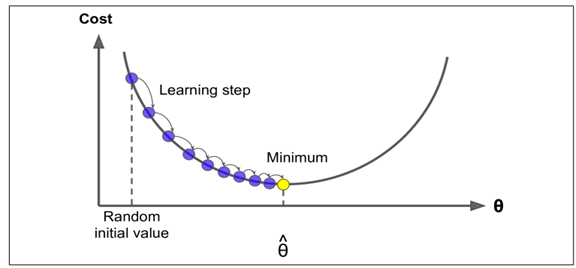

-   On left side as weight will increase , the loss will reduce so new weight = old weight + lr*slope, While on right side new weight will need to reduce  to reach that minimum.

-  So actually in gradient descent when you start with at any postion of loss we need to move in steepest slope towards downward that why we subtract.
-  
-  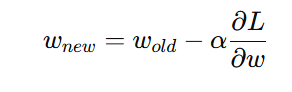

-  If it is the matter of maximum than we need to add.
-   More over if we go for partial derivative the result is :
-   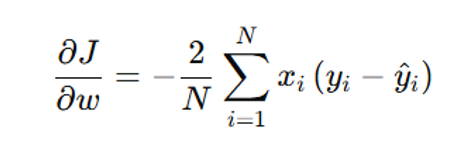
-   by nature it is negative. So loss are negative than to reach minimum we need to increase weight which happen on left side.
-   But once we reach at a value where slope is zero we assume loss is minimum and such value of weight are optimum.
-   If still increase weight slope will no longer will remain zero and on right side by default weight will need to reduce to get slope again zero

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
print(dir(sklearn.linear_model))

In [ ]:
gd_model = SGDRegressor()
gd_model.fit(x_train_sc,y_train)

## SGDRegressor
- (alpha=0.0001,max_iter=1000,tol=0.001,learning_rate='adaptive',eta0=0.01,,n_iter_no_change=5)
- 
## Key Parameters for Tuning SGDRegressor
1. **alpha:** Constant that multiplies the regularization term. Also known as the regularization strength; must be a positive float.
Typical values: [0.0001, 0.001, 0.01, 0.1, 1, 10]

2. **learning_rate:** The learning rate schedule. 
Options include:
'constant': eta = eta0
'optimal': eta = 1.0 / (t + t0)
'invscaling': eta = eta0 / pow(t, power_t)
'adaptive': eta = eta0, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss, the current learning rate is divided by 5.

3. **eta0:** The initial learning rate for the ‘constant’, ‘invscaling’, or ‘adaptive’ schedules.
Typical values: [0.0001, 0.001, 0.01, 0.1, 1]

4. **max_iter:** The maximum number of passes over the training data (epochs).
Typical values: [1000, 5000, 10000]

5.**tol:** The stopping criterion. If it is not None, the iterations will stop when (loss > best_loss - tol) for n_iter_no_change consecutive epochs.
Typical values: [1e-3, 1e-4, 1e-5]

6. **penalty:** The penalty (regularization term) to be used. Options include:
'none'
'l2'
'l1'

7.**n_iter_no_change:** Number of iterations with no improvement to wait before early stopping.
Typical values: [5, 10]

In [ ]:
#learning_rate='adaptive', eta0=0.01, max_iter=10000, tol=1e-3

In [ ]:
y_pred_gd_train = gd_model.predict(x_train_sc)
y_pred_gd_test = gd_model.predict(x_test_sc)

In [ ]:
print("GD TRAINING ACCURACY:",r2_score(y_train,y_pred_gd_train))

In [ ]:
print("GD TEST ACCURACY:",r2_score(y_test,y_pred_gd_test))

## Model saving

In [ ]:
import joblib

In [ ]:
# Save Linear Regression model
joblib.dump(lm, r"D:\desktop\Iinear_model\linear_regression_model.pkl"")
print('lm saved as linear_regression_model.pkl')
"D:\desktop\linear_regression_model.pkl"

In [ ]:
# Save Ridge Regression model
joblib.dump(ridge, 'ridge_model.pkl')
print('ridge saved as ridge_model.pkl')

# Save Lasso Regression model
joblib.dump(lasso, 'lasso_model.pkl')
print('lasso saved as lasso_model.pkl')

# Save SGD Regressor model
joblib.dump(gd_model, 'sgd_model.pkl')
print('gd_model saved as sgd_model.pkl')


## **---->ENCODING CONCEPT:**

## **--->LABEL ENCODING:**
### - Label encoding is a technique used to convert categorical data into numerical data, which is often necessary for machine learning models that can only handle numerical inputs.
### - Convert Address type from object to category than into integer
### - Categorical Data Type: This is a special data type in pandas which is useful for columns that have a limited number of unique values 
### -It  helps to save memory and can make certain operations more efficient.
### -The cat.codes attribute of a categorical column returns the numeric codes corresponding to each category. 
### -Each unique category in the 'Address' column is assigned a unique integer code.
## **----> ONE HOT ENCODING:**
### - One-hot encoding is another technique used to convert categorical data into a format that can be provided to ML algorithms. 
### - It improves predictions. 
### - One-hot encoding creates a new binary (0,1) column for each category.
### - However it increases number of columns
### - It is in practie that after one hot encoding we must drop one column from data set.
### - Here I applied both method for 'ADDRESS'column for your information.
### - But commented one hot encoding, you can check its behaviour.

In [ ]:
# LABEL ENCODING
#USAHOUSING['Address'] = USAHOUSING['Address'].astype('category')
#USAHOUSING['Address'] = USAHOUSING['Address'].cat.codes

In [ ]:
#ONE HOT ENcoding
#USAHOUSING = pd.get_dummies(USAHOUSING,columns = ['Address'],prefix='Address')

# When Scaling Is Needed
- Scaling is important for:

- Ridge

- Lasso

- ElasticNet

- KNN

- SVM

- Neural Networks

# **FEATURE SCALING: Very important while using graident descent approach how ever give poor result with OLS approach.**
#### - Distance-based algorithms (e.g., KNN, SVM) perform better with scaled features because they compute distances based on feature values. 
#### - If the features are on different scales, the algorithm might bias towards features with larger scales.
#### - Feature scaling is a crucial preprocessing step in machine learning that transforms the features of your data so that they are on a similar scale.
#### - This can improve the performance and convergence speed of many algorithms.
#### - ONLY WITH INDEPENDENT VARIABLE
#### - FIRST SPLIT DATA INTO DEPENDENT AND INDEPENDENT VARIABLE

In [ ]:
# LinearRegression (Normal Equation – No Gradient Descent)
# Ridge (Has Solver Options Including Gradient Descent)
# model = Ridge(solver='sag')  # or 'saga'
# 


# Cross-validation is for:
- Model comparison
- Hyperparameter tuning
- Stability check

# Which Type of CV to Use?

| Situation                 | Recommended CV    |
| ------------------------- | ----------------- |
| Regression                | K-Fold (5 or 10)  |
| Imbalanced classification | Stratified K-Fold |
| Small dataset             | 10-fold           |
| Very small dataset        | LOOCV             |
| Time-series               | TimeSeriesSplit   |


Full Data
   ↓
Train/Test Split
   ↓
Cross-Validation on Train
   ↓
Choose Model
   ↓
Final Evaluation on Test

# Linear Regression with CV

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()
# Define K-Fold Splitting
kf = KFold(n_splits=10, shuffle=True, random_state=42)
# Perform Cross-Validation
cv_mse = cross_val_score(
    model,
    x_train,
    y_train,
    scoring='neg_mean_squared_error',
    cv=kf
)

cv_rmse = np.sqrt(np.mean(np.abs(cv_mse)))

print("Cross-Validated RMSE:", cv_rmse)

In [ ]:
cv_mse = np.mean(np.abs(cv_mse))
cv_mse

# Cross-Validated R²

In [ ]:
cv_r2 = cross_val_score(
    model,
    x_train,
    y_train,
    scoring='r2',
    cv=kf
)

print("Cross-Validated R2:", np.mean(cv_r2))

In [ ]:
from sklearn.model_selection import cross_validate

scoring = {
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

cv_results = cross_validate(
    model,
    x_train,
    y_train,
    cv=10,
    scoring=scoring
)

cv_rmse = np.sqrt(-cv_results['test_mse'].mean())
cv_r2 = cv_results['test_r2'].mean()

print("CV RMSE:", cv_rmse)
print("CV R2:", cv_r2)

# For Ridge / Lasso (Better Practice)

In [ ]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=10
)

ridge_cv.fit(x_train, y_train)

print("Best alpha:", ridge_cv.alpha_)

In [ ]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(
    alphas=np.logspace(-4, 4, 100),
    cv=10,
    max_iter=10000
)

lasso_cv.fit(x_train, y_train)

print("Best alpha:", lasso_cv.alpha_)

In [ ]:
# SK Learn Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

pipeline = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4,4,100), cv=10, max_iter=10000)
)

pipeline.fit(x_train, y_train)

best_alpha = pipeline.named_steps['lassocv'].alpha_
print("Best alpha:", best_alpha)

In [ ]:
y_pred_train = pipeline.predict(x_train)
print("Training R2:", r2_score(y_train, y_pred_train))